In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers , models
from tensorflow.keras.models import load_model
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment

In [6]:
# Load dataset
with np.load("../data/mnist.npz") as data:
    x_train_raw, y_train = data["x_train"], data["y_train"]
    x_test_raw, y_test = data["x_test"], data["y_test"]

# Preprocess for training
x_train = x_train_raw.reshape(-1, 28, 28, 1)/255.00
x_test  = x_test_raw.reshape(-1, 28, 28, 1)/255.00

In [7]:
def _show(image, ax=None):
    if ax == None:
        plt.imshow(image, cmap="gray")
        plt.axis("off")
    else:
        ax.imshow(image, cmap="gray")
        ax.axis("off")

def show_encoding(img_1, img_2):
    ax1 = plt.subplot(1, 2, 1)
    _show(img_1, ax1)

    ax2 = plt.subplot(1, 2, 2)
    _show(img_2, ax2)
    
    plt.show()

In [404]:
encoder_input = layers.Input(shape=(28,28,1))

x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_input)
x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.MaxPool2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPool2D(2)(x)

x = layers.Flatten()(x)
x = layers.Dense(256,activation='relu')(x)

latent = layers.Dense(64)(x)

encoder = models.Model(encoder_input, latent)
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 884,512 (3.37 MB)

 Trainable params: 884,512 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_input = layers.Input(shape=(64,))

x = layers.Dense(7*7*64,activation='relu')(latent_input)
x = layers.Reshape((7,7,64))(x)

x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

decoder_output = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

decoder = models.Model(latent_input,decoder_output)
decoder.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3136)           │        34,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,177 (352.25 KB)

 Trainable params: 90,177 (352.25 KB)

 Non-trainable params: 0 (0.00 B)

In [272]:
input_img = encoder_input
encoded = encoder(input_img)
decoded = decoder(encoded)

autoencoder = models.Model(input_img,decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics = ['accuracy']
)

In [273]:
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test,x_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8040 - loss: 0.0452 - val_accuracy: 0.8098 - val_loss: 0.0162
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8116 - loss: 0.0153 - val_accuracy: 0.8110 - val_loss: 0.0137
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8124 - loss: 0.0136 - val_accuracy: 0.8113 - val_loss: 0.0130
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8123 - loss: 0.0127 - val_accuracy: 0.8118 - val_loss: 0.0123
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8125 - loss: 0.0121 - val_accuracy: 0.8119 - val_loss: 0.0119


In [ ]:
encoder.save("../models/encoder_64D.keras")
autoencoder.save("../models/autoencoder_64D.keras")

In [ ]:
encoder = load_model("../models/encoder_64D.keras")
autoencoder = load_model("../models/autoencoder_64D.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


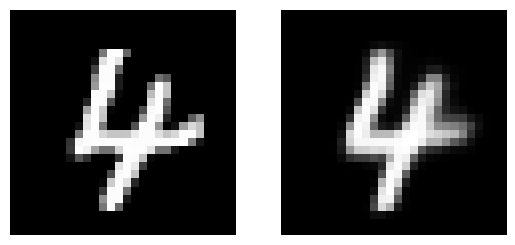

In [18]:
seed = np.random.randint(0, 60000)
img = x_train[seed]
pre_img = autoencoder.predict(np.array([img for _ in range(32)]))[0]
show_encoding(img.reshape(28, 28), pre_img.reshape(28, 28))

In [19]:
features = encoder.predict(x_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [20]:
kmeans = KMeans(n_clusters=10,n_init=20)
y_pred = kmeans.fit_predict(features)

cluster_centers = kmeans.cluster_centers_

In [21]:
class ClusteringLayer(layers.Layer):

    def __init__(self,n_clusters,weights=None,alpha=1.0,**kwargs):
        super().__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights

    def build(self,input_shape):
        self.clusters = self.add_weight(
            shape=(self.n_clusters,input_shape[1]),
            initializer='glorot_uniform',
            trainable=True
        )

        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)

    def call(self,inputs):

        q = 1.0/(1.0+(tf.reduce_sum(
            tf.square(tf.expand_dims(inputs,1)-self.clusters),axis=2
        )/self.alpha))

        q **= (self.alpha+1.0)/2.0
        q = tf.transpose(tf.transpose(q)/tf.reduce_sum(q,axis=1))

        return q

In [22]:
clustering_layer = ClusteringLayer(
    10,
    weights=[cluster_centers]
)(encoder.output)

dec_model = models.Model(
    inputs=encoder.input,
    outputs=clustering_layer
)

dec_model.compile(
    optimizer='adam',
    loss='kld'
)

In [23]:
def target_distribution(q):

    weight = q**2 / q.sum(0)

    return (weight.T / weight.sum(1)).T

In [27]:
maxiter = 1000
update_interval = 100
batch_size = 256

index = 0

for ite in range(maxiter):

    # update target distribution
    if ite % update_interval == 0:
        q = dec_model.predict(x_train, verbose=0)
        p = target_distribution(q)

        print("Iteration:", ite)

    # batch selection
    start = index * batch_size
    end = (index + 1) * batch_size

    x_batch = x_train[start:end]
    p_batch = p[start:end]

    # training step
    loss = dec_model.train_on_batch(x_batch, p_batch)

    index += 1

    # reset index
    if end >= x_train.shape[0]:
        index = 0


Iteration: 0
Iteration: 100
Iteration: 200


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000002B1CF96D890>>
Traceback (most recent call last):
  File "c:\Users\Sazgar\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Iteration: 300
Iteration: 400
Iteration: 500
Iteration: 600
Iteration: 700
Iteration: 800
Iteration: 900


In [28]:
q = dec_model.predict(x_train)
y_pred = q.argmax(1)

def cluster_accuracy(y_true,y_pred):

    D = max(y_pred.max(),y_true.max())+1
    w = np.zeros((D,D))

    for i in range(y_pred.size):
        w[y_pred[i],y_true[i]] += 1

    ind = linear_sum_assignment(w.max()-w)

    return sum(w[i,j] for i,j in zip(ind[0],ind[1])) / y_pred.size


print("Clustering Accuracy:",cluster_accuracy(y_train,y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Clustering Accuracy: 0.8838333333333334


In [ ]:
q = dec_model.predict(x_train)
cluster_labels = q.argmax(axis=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


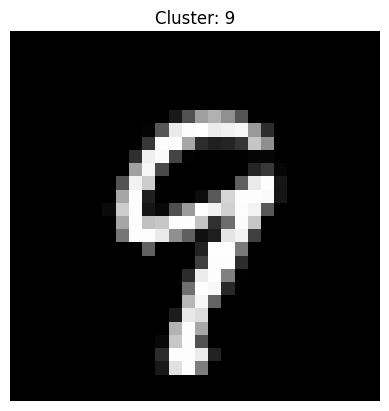

In [421]:
class_id = 9
_class = {0:4, 1:7, 2:6, 3:3, 4:5, 5:0, 6:1, 7:2, 8:9, 9:8 }
cluster_id = _class[class_id]

idx = np.where(cluster_labels == cluster_id)[0]

random_index = np.random.choice(idx)

img = x_train[random_index]

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Cluster: {class_id}")
plt.axis('off')
plt.show()
